# Figure 7: SoA comparison segusm

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

pd.set_option('display.max_rows', 1000)

gpu_dataframe = pd.concat(map(pd.read_csv, glob(join('..', f"*gpu*0.0001*.csv"))))
gpu_dataframe["time_us"] = gpu_dataframe["time_s"] * 1000000
gpu_dataframe["operator"] = "A5000_torch_scatter"
gpu_dataframe["nrow"]=gpu_dataframe["nrows"]-1
tot_dataframe = pd.concat(map(pd.read_csv, glob(join('..', f"*ascend*.csv"))))
tot_dataframe = pd.concat([tot_dataframe,gpu_dataframe])

In [ ]:
tot_dataframe.head(10)

,operator,dtype,size,nrow,density,time_us,benchname,nnz,nrows,outputSize,time_s
0,segsum0.0001,fp16,10000.0,10000,0.0001,238.700000,NaN,NaN,NaN,NaN,NaN
1,segsum0.0001,fp16,12100.0,11000,0.0001,231.490000,NaN,NaN,NaN,NaN,NaN
2,segsum0.0001,fp16,14400.0,12000,0.0001,227.800000,NaN,NaN,NaN,NaN,NaN
3,segsum0.0001,fp16,16900.0,13000,0.0001,224.150000,NaN,NaN,NaN,NaN,NaN
4,segsum0.0001,fp16,19600.0,14000,0.0001,227.540000,NaN,NaN,NaN,NaN,NaN
5,segsum0.0001,fp16,22500.0,15000,0.0001,213.060000,NaN,NaN,NaN,NaN,NaN
6,segsum0.0001,fp16,25600.0,16000,0.0001,216.470000,NaN,NaN,NaN,NaN,NaN
7,segsum0.0001,fp16,28900.0,17000,0.0001,214.620000,NaN,NaN,NaN,NaN,NaN
8,segsum0.0001,fp16,32400.0,18000,0.0001,213.630000,NaN,NaN,NaN,NaN,NaN
9,segsum0.0001,fp16,36100.0,19000,0.0001,211.110000,NaN,NaN,NaN,NaN,NaN


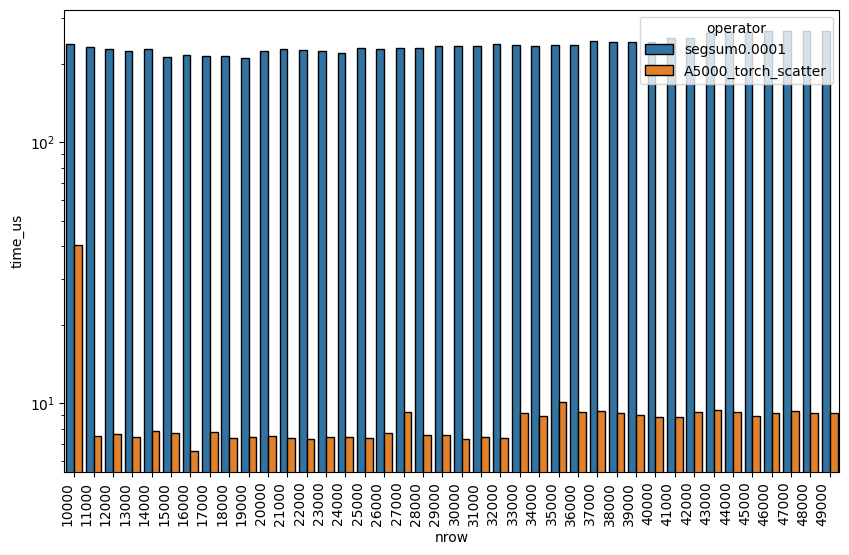

In [ ]:
plt.figure(figsize=(13,6))
ax = sns.barplot(data=tot_dataframe, x="nrow", y="time_us", hue="operator", edgecolor="black")
plt.yscale("log")   
plt.xticks(rotation=90, ha='right')

plt.savefig("segsum_soa_comparison.pdf")


